# Checkpoint 1 – Quem é o mago mais habilidoso do universo Harry Potter?

**Nível de significância:** α = 0,10

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Guiroselli/cp1Nemec/blob/main/checkpoint_magos.ipynb)

Técnicas usadas (todas das Aulas 1, 2 e 3 de Teste de Hipóteses): teste de **Shapiro**, teste de **Friedman**
(3+ condições pareadas), pós-hoc com **Wilcoxon pareado + correção de Bonferroni** e **teste t pareado (ttest_rel)** no desempate.

## 1. Definição de "mais habilidoso"

O mago mais habilidoso é aquele que **executa magia com a maior qualidade técnica**. Criei o
**Índice de Habilidade (IH)** de cada execução:

$$IH = \frac{precisão + potência + controle}{3}$$

As três variáveis são numéricas contínuas na mesma escala (0 a 100), então cada uma tem o mesmo peso.

**Critérios de desempate** (só se o critério principal não separar os melhores):
1. Menor **tempo de execução** (quem faz com a mesma qualidade mais rápido é mais habilidoso);
2. Maior **taxa de sucesso**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ALPHA = 0.10

## 2. Carregando os dados

In [2]:
URL = "https://raw.githubusercontent.com/Guiroselli/cp1Nemec/main/checkpoint_magos_dados.csv"
if os.path.exists("checkpoint_magos_dados.csv"):
    df = pd.read_csv("checkpoint_magos_dados.csv")   # arquivo enviado para o Colab
else:
    df = pd.read_csv(URL)                            # lê direto do GitHub
df.head()

,execucao_id,prova_id,mago,categoria,tarefa,dificuldade,pressao,resistencia_alvo,alvo_movel,contexto,tempo_execucao_s,precisao_pct,potencia_pct,controle_pct,sucesso,dano_colateral
0,E00001,P001,Albus Dumbledore,Ataque,Expelliarmus,1,10,1,0,duelo_real,11.08,83.18,83.76,83.17,1,0
1,E00002,P002,Albus Dumbledore,Ataque,Estupefaca,3,7,9,0,missao,14.97,77.64,76.94,81.93,1,0
2,E00003,P003,Albus Dumbledore,Ataque,Bombarda,4,3,4,0,treino,13.89,79.25,88.36,85.62,1,0
3,E00004,P004,Albus Dumbledore,Ataque,Confringo,4,9,8,0,duelo_real,13.79,85.30,87.36,81.13,0,0
4,E00005,P005,Albus Dumbledore,Ataque,Expelliarmus,2,4,9,1,exame,14.48,81.97,81.01,78.82,1,0


In [3]:
print(df.shape)
print("Magos:", df['mago'].nunique(), "| Provas:", df['prova_id'].nunique())
# Cada prova_id (mesma condição experimental) foi feita pelos 12 magos -> DADOS PAREADOS
df.groupby('prova_id')['mago'].nunique().value_counts()

(1440, 16)
Magos: 12 | Provas: 120


mago
12    120
Name: count, dtype: int64

## 3. Índice de Habilidade

In [4]:
df['IH'] = df[['precisao_pct', 'potencia_pct', 'controle_pct']].mean(axis=1)

# Tabela larga: cada linha é uma prova, cada coluna um mago (formato pareado)
ih = df.pivot(index='prova_id', columns='mago', values='IH')

resumo = pd.DataFrame({'IH_media': ih.mean(), 'IH_mediana': ih.median(), 'IH_desvio': ih.std()})
resumo = resumo.sort_values('IH_mediana', ascending=False)
resumo.round(3)

,IH_media,IH_mediana,IH_desvio
mago,,,
Albus Dumbledore,82.150,82.387,2.932
Severus Snape,81.515,81.457,3.561
Gellert Grindelwald,80.744,81.032,3.937
Hermione Granger,80.987,80.948,3.058
Lord Voldemort,79.983,80.477,4.506
Minerva McGonagall,79.673,79.887,4.373
Filius Flitwick,79.751,79.728,4.525
Kingsley Shacklebolt,78.243,78.327,3.640
Remus Lupin,77.174,77.215,3.455


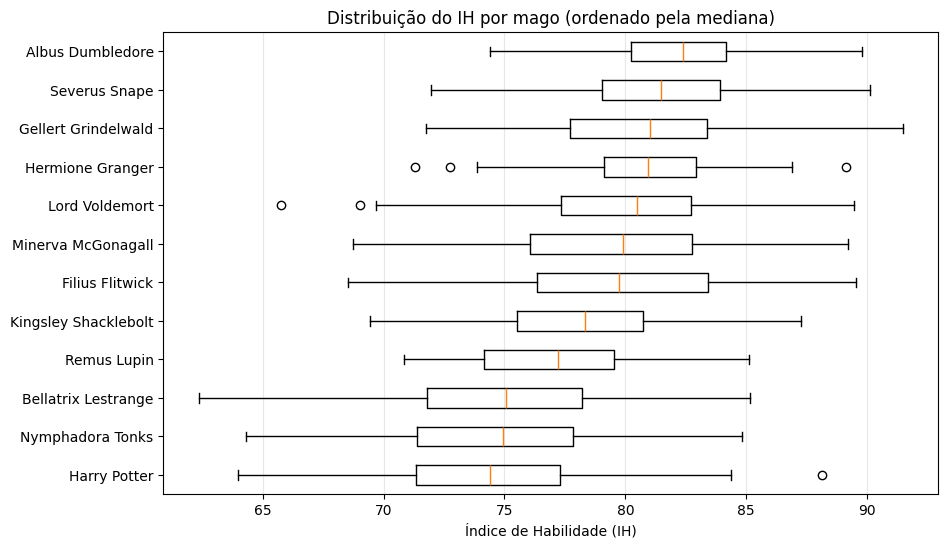

In [5]:
ordem = resumo.index
plt.figure(figsize=(10, 6))
plt.boxplot([ih[m] for m in ordem], vert=False)
plt.yticks(range(1, len(ordem) + 1), ordem)
plt.gca().invert_yaxis()
plt.xlabel('Índice de Habilidade (IH)')
plt.title('Distribuição do IH por mago (ordenado pela mediana)')
plt.grid(axis='x', alpha=.3)
plt.show()

## 4. Estratégia do experimento

1. **Tipo de dado:** os 12 magos fizeram as mesmas 120 provas → **dados pareados** com **3 ou mais condições**.
2. **Pressuposto de normalidade:** teste de **Shapiro** no IH de cada mago (H0: dados normais).
3. **Teste global:** como são 12 condições pareadas, uso o **Friedman** (teste para 3+ condições pareadas; não exige normalidade).
   - H0: as distribuições do IH dos 12 magos são iguais
   - H1: pelo menos um mago é diferente
4. **Pós-hoc:** o Friedman diz que existe diferença, mas não onde. Então comparo o **líder** (maior mediana)
   com cada um dos outros 11 usando **Wilcoxon pareado unilateral** e corrijo os p-valores com **Bonferroni**
   (p × 11), para controlar o acúmulo de erro tipo I.
   - H0: o líder não é melhor que o mago comparado
   - H1: o líder é melhor que o mago comparado
5. Quem **não** for significativamente pior que o líder fica **empatado** e vai para o desempate.

### 4.1 Shapiro – normalidade do IH de cada mago

In [6]:
shapiro = pd.DataFrame({m: stats.shapiro(ih[m]) for m in ih}, index=['W', 'p_valor']).T
shapiro['normal?'] = np.where(shapiro['p_valor'] >= ALPHA, 'Sim', 'Não')
shapiro.sort_values('p_valor').round(4)

,W,p_valor,normal?
Remus Lupin,0.9760,0.0306,Não
Filius Flitwick,0.9842,0.1757,Sim
Minerva McGonagall,0.9851,0.2115,Sim
Bellatrix Lestrange,0.9853,0.2184,Sim
Hermione Granger,0.9893,0.4753,Sim
Severus Snape,0.9894,0.4783,Sim
Lord Voldemort,0.9897,0.5112,Sim
Nymphadora Tonks,0.9906,0.5929,Sim
Gellert Grindelwald,0.9916,0.6857,Sim
Albus Dumbledore,0.9917,0.6926,Sim


In [7]:
todos_normais = (shapiro['p_valor'] >= ALPHA).all()
print('Todos os magos têm IH normal?', todos_normais)
print('-> Nem todos são normais e os dados são pareados com 12 condições: usamos Friedman (não paramétrico).')

Todos os magos têm IH normal? False
-> Nem todos são normais e os dados são pareados com 12 condições: usamos Friedman (não paramétrico).


### 4.2 Friedman – existe diferença entre os magos?

In [8]:
stat, p_friedman = stats.friedmanchisquare(*[ih[m] for m in ih])
print(f'Friedman: estatística = {stat:.2f} | p-valor = {p_friedman:.3e}')
print('Rejeita H0: existe diferença de habilidade entre os magos.' if p_friedman < ALPHA
      else 'Não rejeita H0: não há evidência de diferença.')

Friedman: estatística = 494.83 | p-valor = 4.055e-99
Rejeita H0: existe diferença de habilidade entre os magos.


### 4.3 Pós-hoc – líder vs. demais (Wilcoxon pareado + Bonferroni)

In [9]:
lider = resumo.index[0]
n_comp = len(resumo) - 1
print('Líder (maior mediana de IH):', lider)

linhas = []
for mago in resumo.index[1:]:
    p = stats.wilcoxon(ih[lider], ih[mago], alternative='greater').pvalue
    p_bonf = min(p * n_comp, 1.0)
    linhas.append({'comparado_com': mago,
                   'dif_mediana': (ih[lider] - ih[mago]).median(),
                   'p_valor': p, 'p_bonferroni': p_bonf,
                   'decisao': 'Rejeita H0 (líder é melhor)' if p_bonf < ALPHA else 'Não rejeita H0 (EMPATE)'})

posthoc = pd.DataFrame(linhas)
posthoc.round(5)

Líder (maior mediana de IH): Albus Dumbledore


,comparado_com,dif_mediana,p_valor,p_bonferroni,decisao
0,Severus Snape,1.14667,0.04816,0.52974,Não rejeita H0 (EMPATE)
1,Gellert Grindelwald,1.43833,0.00026,0.00289,Rejeita H0 (líder é melhor)
2,Hermione Granger,1.08833,0.00152,0.01674,Rejeita H0 (líder é melhor)
3,Lord Voldemort,1.64667,0.00000,0.00001,Rejeita H0 (líder é melhor)
4,Minerva McGonagall,2.16000,0.00000,0.00000,Rejeita H0 (líder é melhor)
5,Filius Flitwick,2.44000,0.00000,0.00001,Rejeita H0 (líder é melhor)
6,Kingsley Shacklebolt,3.87500,0.00000,0.00000,Rejeita H0 (líder é melhor)
7,Remus Lupin,5.25500,0.00000,0.00000,Rejeita H0 (líder é melhor)
8,Bellatrix Lestrange,7.22167,0.00000,0.00000,Rejeita H0 (líder é melhor)
9,Nymphadora Tonks,7.23833,0.00000,0.00000,Rejeita H0 (líder é melhor)


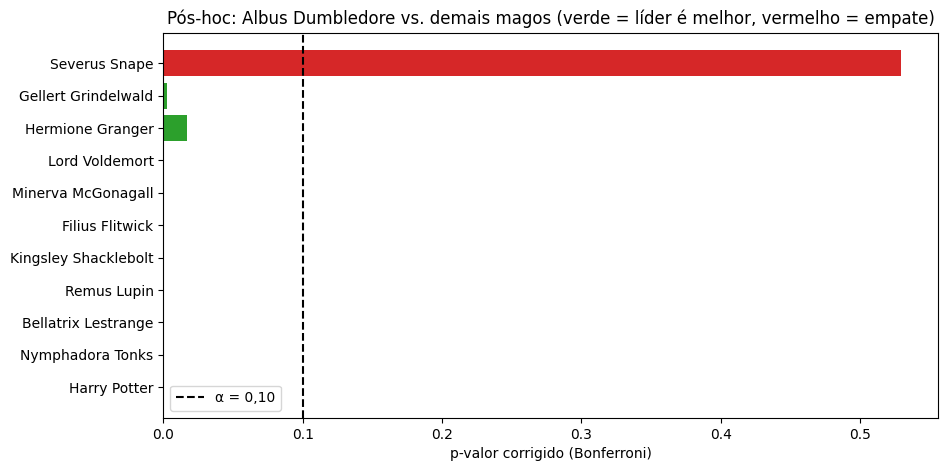

Empatados no critério principal: ['Albus Dumbledore', 'Severus Snape']


In [10]:
plt.figure(figsize=(10, 5))
cores = ['tab:green' if p < ALPHA else 'tab:red' for p in posthoc['p_bonferroni']]
plt.barh(posthoc['comparado_com'], posthoc['p_bonferroni'], color=cores)
plt.axvline(ALPHA, color='k', ls='--', label='α = 0,10')
plt.gca().invert_yaxis()
plt.xlabel('p-valor corrigido (Bonferroni)')
plt.title(f'Pós-hoc: {lider} vs. demais magos (verde = líder é melhor, vermelho = empate)')
plt.legend()
plt.show()

empatados = [lider] + posthoc.loc[posthoc['p_bonferroni'] >= ALPHA, 'comparado_com'].tolist()
print('Empatados no critério principal:', empatados)

## 5. Desempate 1 – Tempo de execução (menor é melhor)

Continua sendo pareado (mesmas provas). Com 2 magos empatados, verifico a normalidade da **diferença** de tempo com Shapiro:
- se for normal → **teste t pareado (ttest_rel)**;
- se não for → **Wilcoxon pareado**.

Hipóteses (bilateral, pois não sei a priori quem é mais rápido):
- H0: não há diferença no tempo de execução
- H1: há diferença no tempo de execução

In [11]:
tempo = df.pivot(index='prova_id', columns='mago', values='tempo_execucao_s')

vencedor = lider
if len(empatados) == 2:
    a, b = empatados
    dif = tempo[a] - tempo[b]
    p_shap = stats.shapiro(dif).pvalue
    print(f'Tempo médio: {a} = {tempo[a].mean():.2f}s | {b} = {tempo[b].mean():.2f}s')
    print(f'Shapiro da diferença: p = {p_shap:.4f} ->', 'normal' if p_shap >= ALPHA else 'não normal')
    if p_shap >= ALPHA:
        p = stats.ttest_rel(tempo[a], tempo[b]).pvalue
        print(f'Teste t pareado: p = {p:.5f}')
    else:
        p = stats.wilcoxon(tempo[a], tempo[b]).pvalue
        print(f'Wilcoxon pareado: p = {p:.5f}')
    if p < ALPHA:
        vencedor = a if tempo[a].mean() < tempo[b].mean() else b
        print(f'Rejeita H0 -> {vencedor} é significativamente mais rápido e vence o desempate.')
    else:
        print('Não rejeita H0 -> continua empatado, vai para o desempate 2 (taxa de sucesso).')
        suc = df.groupby('mago')['sucesso'].mean()
        vencedor = suc[empatados].idxmax()
elif len(empatados) > 2:
    # Mais de 2 empatados: repetir a estratégia (Friedman + pós-hoc) só entre eles, usando o tempo
    print('Mais de dois empatados:', empatados)
else:
    print('Não houve empate.')

print('\nMAGO MAIS HABILIDOSO:', vencedor)

Tempo médio: Albus Dumbledore = 13.41s | Severus Snape = 13.00s


Shapiro da diferença: p = 0.8891 -> normal
Teste t pareado: p = 0.00028
Rejeita H0 -> Severus Snape é significativamente mais rápido e vence o desempate.

MAGO MAIS HABILIDOSO: Severus Snape


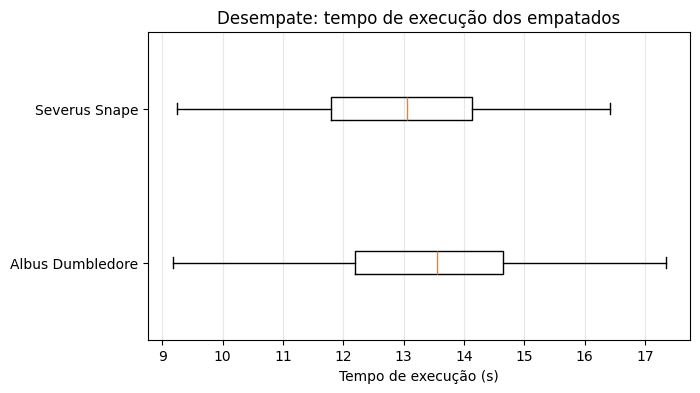

In [12]:
plt.figure(figsize=(7, 4))
plt.boxplot([tempo[m] for m in empatados], vert=False)
plt.yticks(range(1, len(empatados) + 1), empatados)
plt.xlabel('Tempo de execução (s)')
plt.title('Desempate: tempo de execução dos empatados')
plt.grid(axis='x', alpha=.3)
plt.show()

## 6. Conclusão

- **Shapiro:** nem todos os magos têm IH normal (Remus Lupin, p ≈ 0,03 < 0,10).
- **Friedman:** p ≈ 4e-99 → existe diferença de habilidade entre os magos.
- **Pós-hoc (Wilcoxon pareado + Bonferroni):** o líder, **Albus Dumbledore**, foi significativamente melhor que 10 magos,
  mas **empatou com Severus Snape** (p corrigido ≈ 0,53).
- **Desempate (tempo de execução, teste t pareado):** Snape é significativamente mais rápido que Dumbledore (≈ 13,0 s vs. 13,4 s).

**Resultado: Severus Snape é o mago mais habilidoso** segundo o meu critério.